In [2]:
import matplotlib.pyplot as plt
import os
import numpy as np
import tifffile
import sys
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
from mmtrack import plot_cells


In [5]:
def stack_to_kymograph(stack):
    """
    takes a numpyarray of an image in the format (t, y, x) and converts it into a kymograph
    """

    kymograph_gray = []
    for i in range(stack.shape[0]):
        frame = stack[i]
        if frame.ndim == 3:
            kymograph_gray.append(frame, axis=2)
        else:
            kymograph_gray.append(frame)
    
    kymograph = np.concatenate(kymograph_gray, axis =1)
    return kymograph

In [14]:
path_new_mask = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_noKan_Glucose_031125/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/napari_corrections/004_756_corrected.tif'
path_old_mask = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_noKan_Glucose_031125/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_004_region_756_c_0.tif'
path_to_phase_stack = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_noKan_Glucose_031125/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_004_region_756_c_0.tif'

In [19]:
phase_kymo = stack_to_kymograph(tifffile.imread(path_to_phase_stack))
mask_kymo_old=stack_to_kymograph(tifffile.imread(path_old_mask))
mask_kymo_new=stack_to_kymograph(tifffile.imread(path_new_mask))
tab20_cmap = plt.get_cmap("tab20")


In [20]:
colored_mask_old = np.zeros((*mask_kymo_old.shape, 4), dtype=np.float32)  
unique_labels = np.unique(mask_kymo_old)
for label in unique_labels:
    if label > 0: 
        mask_indices = (mask_kymo_old == label)
        colored_mask_old[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
        colored_mask_old[mask_indices, 3] = 1.0  


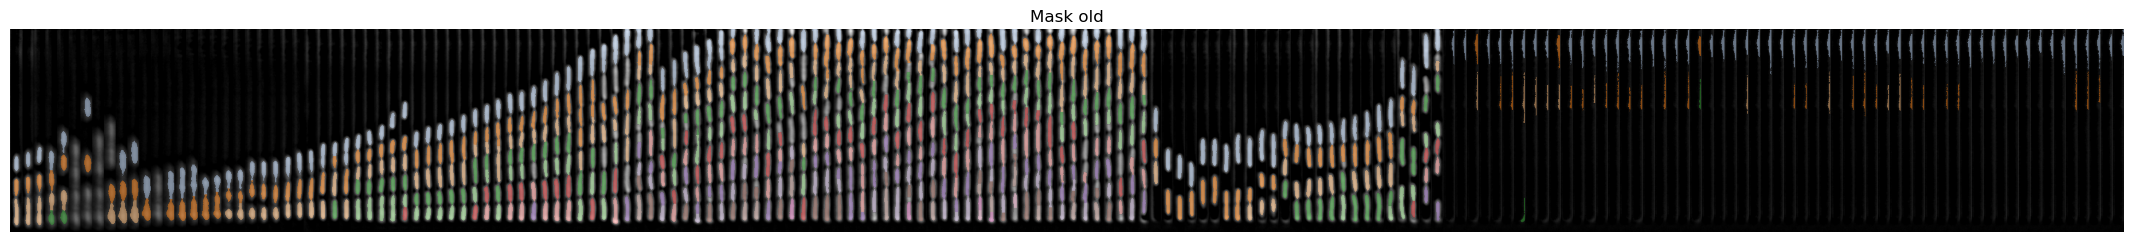

In [28]:
plt.figure(figsize=(60, 20))

plt.subplot(1, 2, 2)
plt.imshow(phase_kymo, cmap='gray')  
plt.imshow(colored_mask_old, alpha=0.5)  
plt.title(f'Mask old')
plt.axis('off')

plt.show()        

In [23]:
colored_mask_new = np.zeros((*mask_kymo_new.shape, 4), dtype=np.float32)  
unique_labels = np.unique(mask_kymo_new)
for label in unique_labels:
    if label > 0: 
        mask_indices = (mask_kymo_new == label)
        colored_mask_new[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
        colored_mask_new[mask_indices, 3] = 1.0  

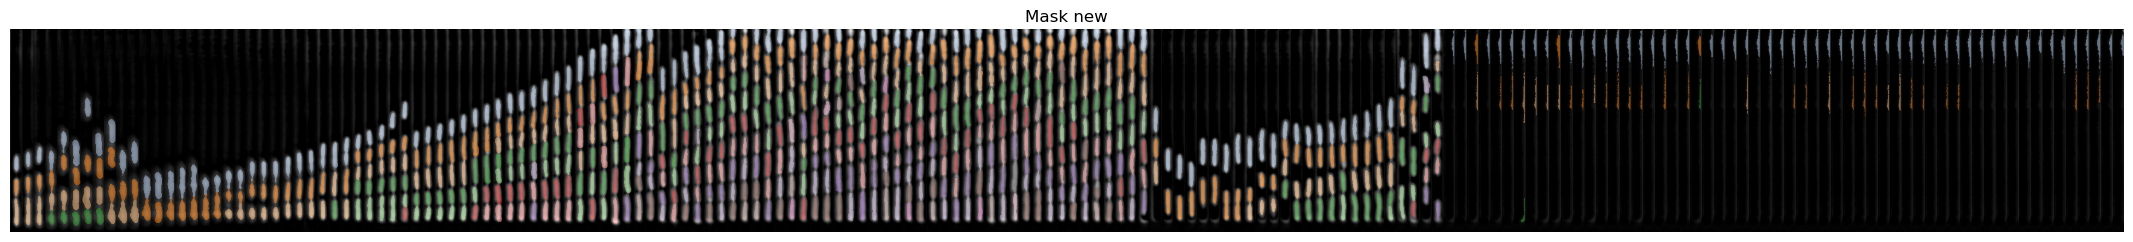

In [29]:
plt.figure(figsize=(60, 20))

plt.subplot(1, 2, 2)
plt.imshow(phase_kymo, cmap='gray')  
plt.imshow(colored_mask_new, alpha=0.5)  
plt.title(f'Mask new')
plt.axis('off')

plt.show()     

In [ ]:
# function that plots phase, fluor, and mask kymograph using current file naming standards
# uses post time_dict files 

def plot_all_functions(experiment):
    base_path =f'/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/{experiment}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted'
    path_to_fluor_stack_dir=f'{base_path}/fluor_kymos'
    path_to_phase_stack_dir=f'{base_path}'
    path_to_labels_stack_dir =f'{base_path}/mask_kymos'
    phase_list = os.listdir(path_to_phase_stack_dir)
    mask_list =os.listdir(path_to_labels_stack_dir)
    fluor_list =os.listdir(path_to_fluor_stack_dir)
    tab20_cmap = plt.get_cmap("tab20")


    for file_name in mask_list:
        if file_name in phase_list and file_name in fluor_list:
            base_name = file_name.replace('.tif', '')
            path_to_mask_stack = f'{path_to_labels_stack_dir}/{file_name}'
            path_to_phase_stack = f'{path_to_phase_stack_dir}/{file_name}'
            path_to_fluor_stack =f'{path_to_fluor_stack_dir}/{file_name}'
            
            phase_kymograph=tifffile.imread(path_to_phase_stack)
            fluor_kymograph=tifffile.imread(path_to_fluor_stack)
            mask_kymograph=tifffile.imread(path_to_mask_stack)

            colored_mask = np.zeros((*mask_kymograph.shape, 4), dtype=np.float32)  
            unique_labels = np.unique(mask_kymograph)
            for label in unique_labels:
                if label > 0: 
                    mask_indices = (mask_kymograph == label)
                    colored_mask[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
                    colored_mask[mask_indices, 3] = 1.0  

            plt.figure(figsize=(12, 8))

            plt.subplot(1, 2, 1)
            plt.imshow(phase_kymograph, cmap='gray')
            plt.title(f'Phase {base_name}')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(phase_kymograph, cmap='gray')  
            plt.imshow(colored_mask, alpha=0.5)  
            plt.title(f'Mask {base_name}')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(fluor_kymograph, cmap='gray')  
            plt.title(f'Fluor {base_name}')
            plt.axis('off')
            
            plt.show()        

In [ ]:
# this function should only plot segmentation labels overlayed on the phase image
def plot_mask(experiment):
    base_path =f'/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/{experiment}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted'
    path_to_phase_stack_dir=f'{base_path}'
    path_to_labels_stack_dir =f'{base_path}/mask_kymos'
    phase_list = os.listdir(path_to_phase_stack_dir)
    mask_list =os.listdir(path_to_labels_stack_dir)
    tab20_cmap = plt.get_cmap("tab20")

    for file_name in mask_list:
        if file_name in phase_list:
            base_name = file_name.replace('.tif', '')
            path_to_mask_stack = f'{path_to_labels_stack_dir}/{file_name}'
            path_to_phase_stack = f'{path_to_phase_stack_dir}/{file_name}'
            
            phase_kymograph=tifffile.imread(path_to_phase_stack)
            mask_kymograph=tifffile.imread(path_to_mask_stack)

            colored_mask = np.zeros((*mask_kymograph.shape, 4), dtype=np.float32)  
            unique_labels = np.unique(mask_kymograph)
            for label in unique_labels:
                if label > 0: 
                    mask_indices = (mask_kymograph == label)
                    colored_mask[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
                    colored_mask[mask_indices, 3] = 1.0  

            plt.figure(figsize=(12, 8))

            plt.imshow(phase_kymograph, cmap='gray')  
            plt.imshow(colored_mask, alpha=0.5)  
            plt.title(f'Mask {base_name}')
            plt.axis('off')
            
            plt.show()        

In [ ]:
# function used to aid in plotting kymographs from Nora's notebook
def plot_kymograph_cells_id(phase_kymograph, fluor_kymograph, full_region_df, folder, fov_id, peak_id, track_id_col='track_id'):
    fig, ax = plt.subplots(1,1, figsize=(40, 10))

    # Get kymograph shape once for both calls
    kymograph_shape = phase_kymograph.shape
    print(kymograph_shape)

    ax.imshow(phase_kymograph, cmap = 'grey')
    plot_cells._plot_cell_masks(ax, full_region_df, kymograph_shape, y_coord_col = 'centroid_y', x_coord_col = 'centroid_x', lineage_col = track_id_col)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f'Phase Kymograph - {folder} FOV: {fov_id}, trench: {peak_id}')

    plt.xlabel("Time frames")
    plt.tight_layout()

    plt.show()

# function used to plot centroids tracked. takes in the base_dir and a pandas dataframe 
# will plot all kymographs in pandas dataframe for testing use a subset dataframe before plotting everything
def plot_kymographs(base_dir, df_for_kymograph_plot):
    """Helper function to load kymograph images and plot predicted lineages."""
    print("\n--- Plotting Predicted Lineages on Kymographs ---")

    # Use pandas to get unique experiment/FOV/trench combinations
    unique_views = df_for_kymograph_plot[['experiment_name', 'FOV', 'trench_id']].drop_duplicates()

    if unique_views.empty:
        print("No unique views to plot.")
        return

    for index, cell_view in unique_views.iterrows():
        exp, fov, trench = cell_view['experiment_name'], cell_view['FOV'], cell_view['trench_id']

        # Path construction based on Stage 4's expected output
        kymo_base_path = os.path.join(base_dir, exp, 'hyperstacked', 'drift_corrected', 'rotated', 'mm_channels',
                                      'subtracted')

        # NOTE: Using the simple naming convention (e.g., '007_992.tif')
        path_to_phase_kymograph = os.path.join(kymo_base_path, f'{fov}_{trench}.tif')
        path_to_fluor_kymograph = os.path.join(kymo_base_path, 'fluor_kymos',
                                               f'{fov}_{trench}.tif')  # Assuming 'fluor' subdirectory

        # Fallback check for file existence
        if not (os.path.exists(path_to_phase_kymograph) and os.path.exists(path_to_fluor_kymograph)):
            print(f"  Skipping {exp}/{fov}/{trench}: Kymograph files not found.")
            continue

        print(f"  -> Plotting {exp}/{fov}/{trench}")

        phase_kymograph = tifffile.imread(path_to_phase_kymograph)
        fluor_kymograph = tifffile.imread(path_to_fluor_kymograph)

        df_view = df_for_kymograph_plot[
            (df_for_kymograph_plot['experiment_name'] == exp) &
            (df_for_kymograph_plot['FOV'] == fov) &
            (df_for_kymograph_plot['trench_id'] == trench)
            ].copy()

        plot_kymograph_cells_id(
            phase_kymograph, fluor_kymograph,
            df_view,
            exp, fov, trench,
            track_id_col='predicted_lineage'
        )


### here is where you can type in the experiment name and it should plot all the available kymographs we have for the experiment!
### you must be connected to oak already to access the images

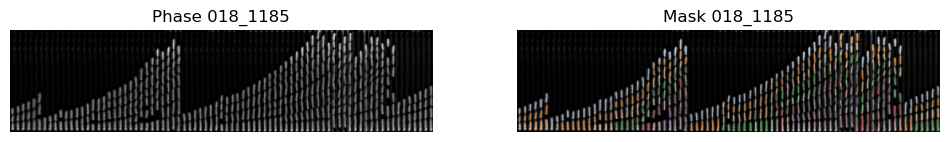

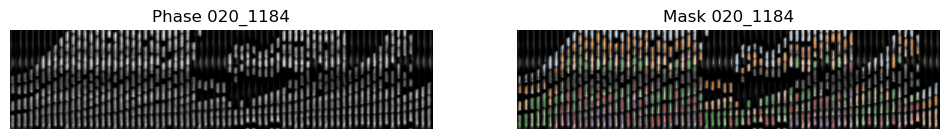

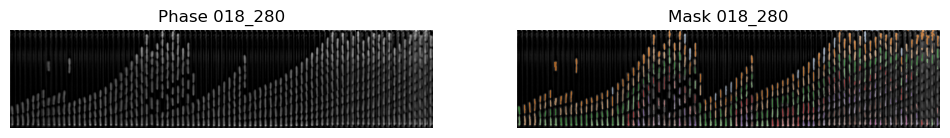

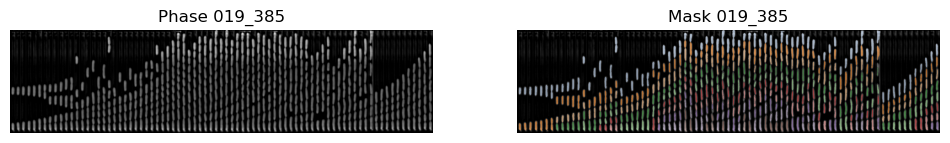

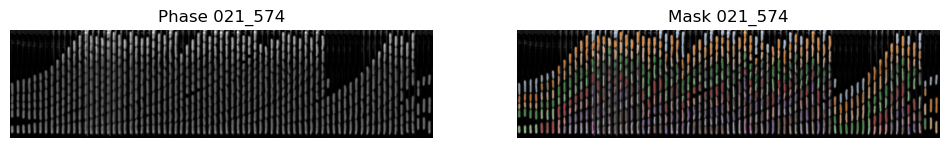

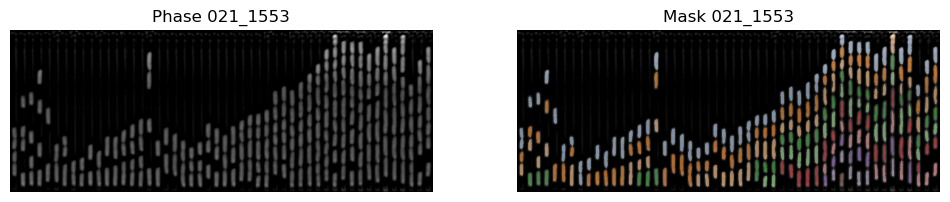

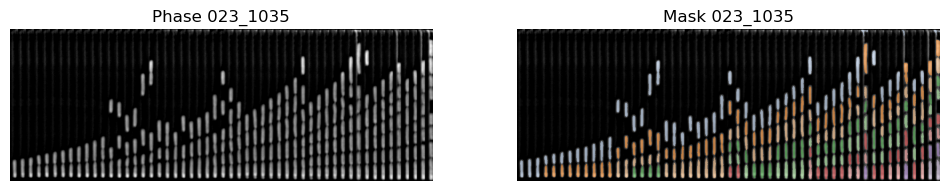

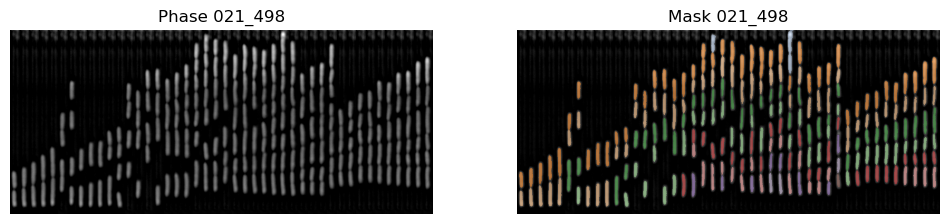

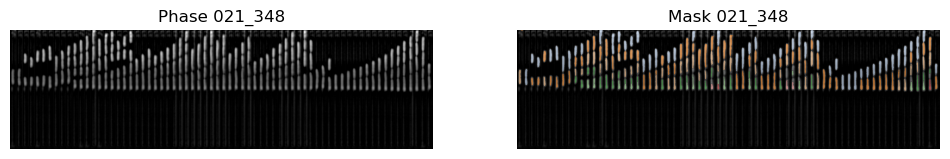

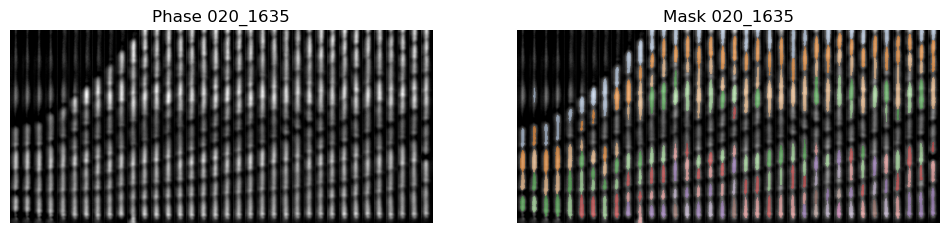

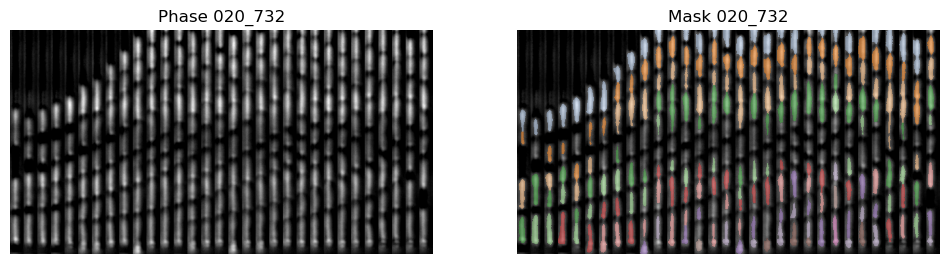

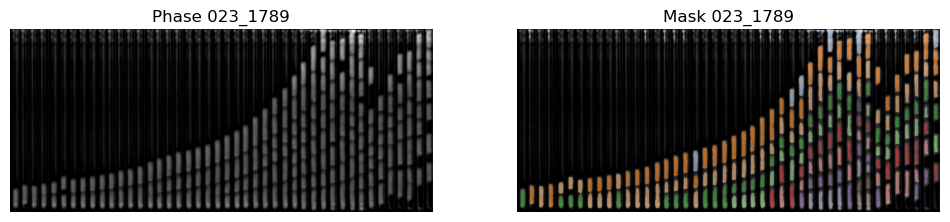

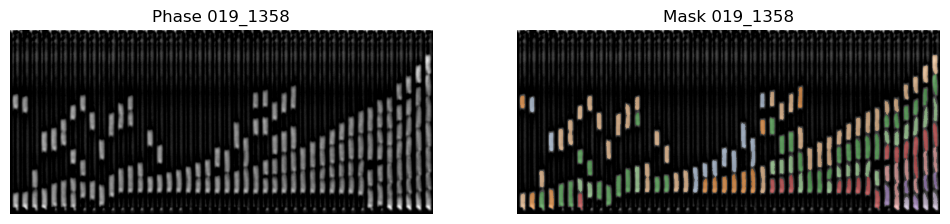

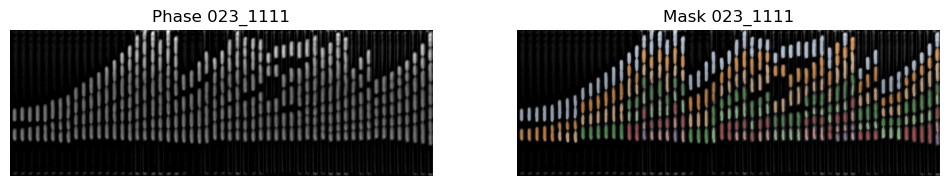

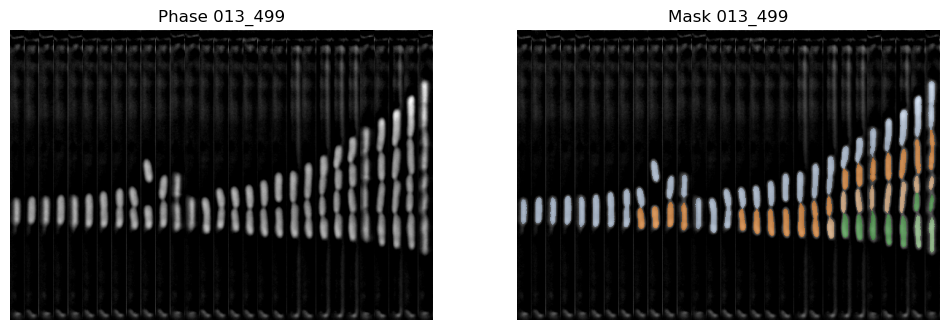

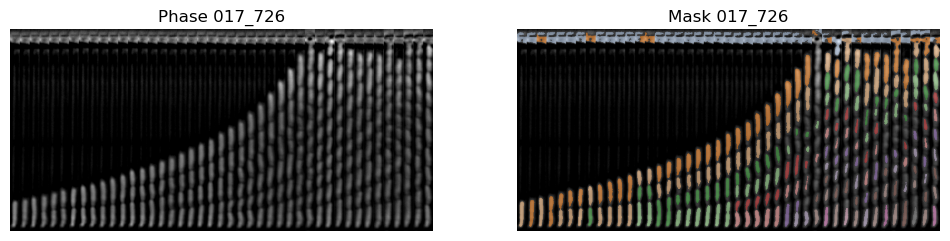

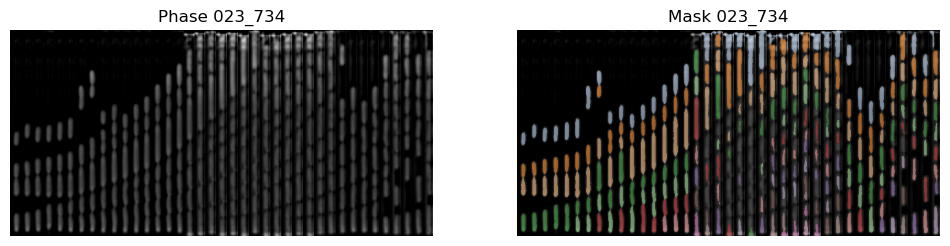

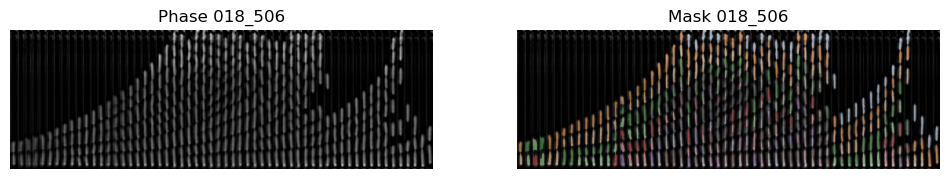

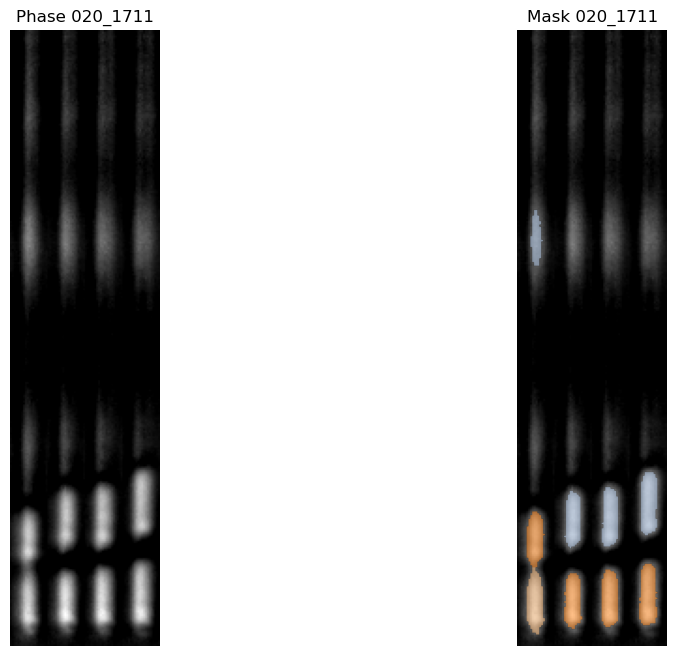

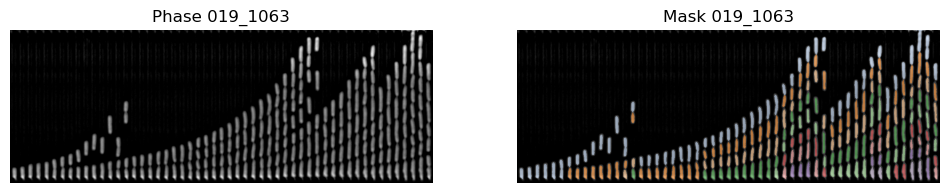

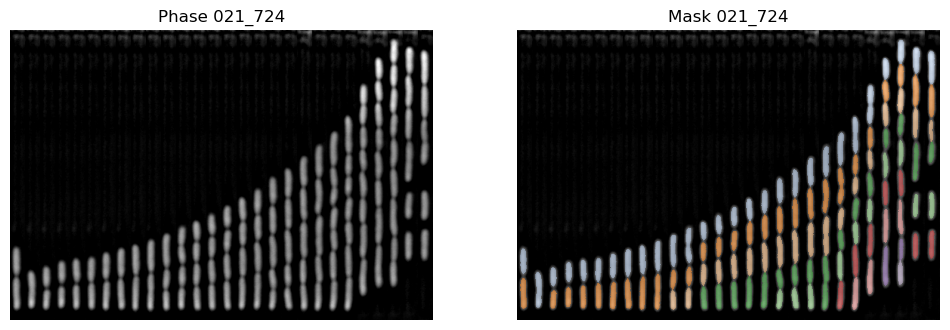

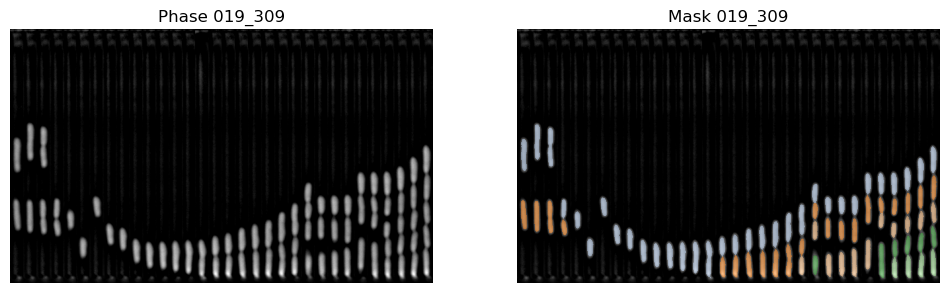

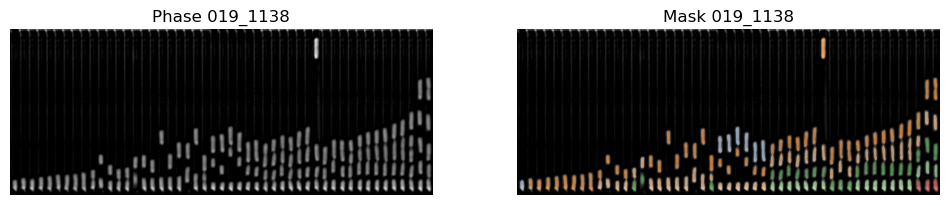

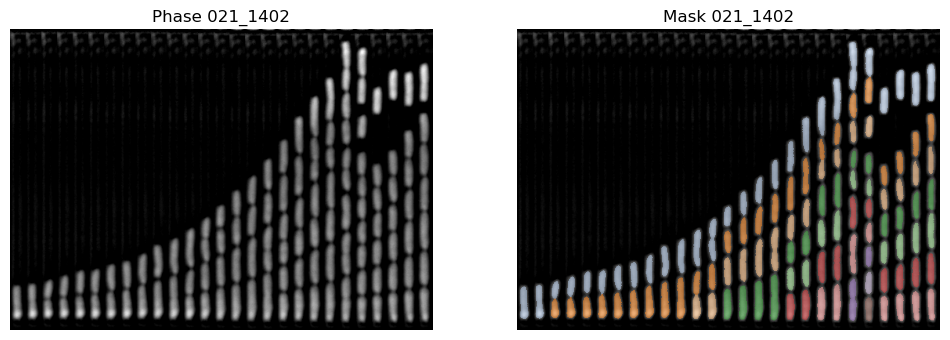

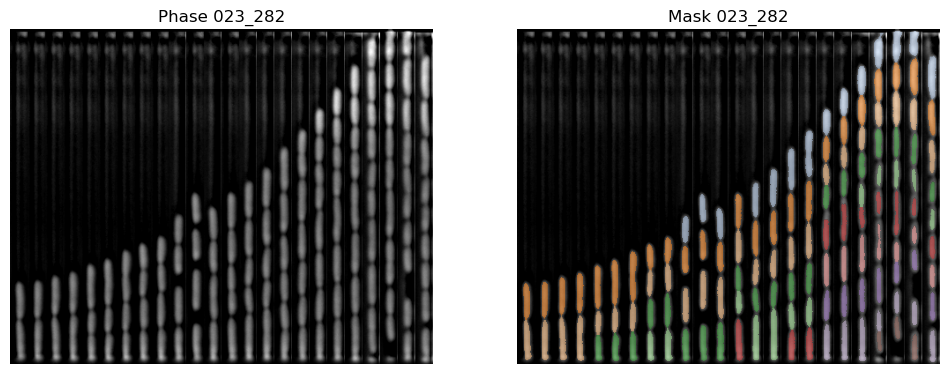

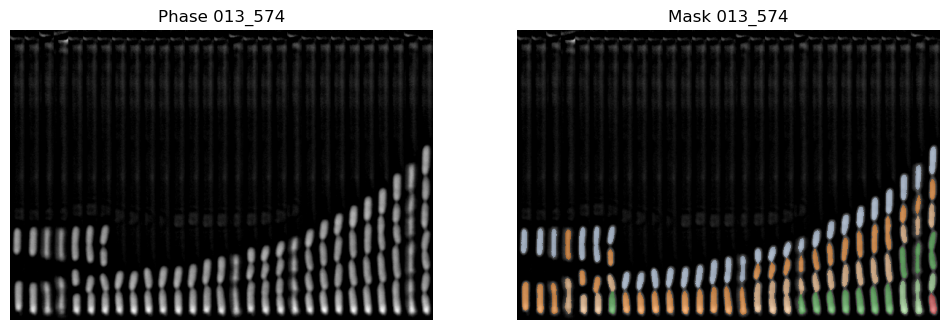

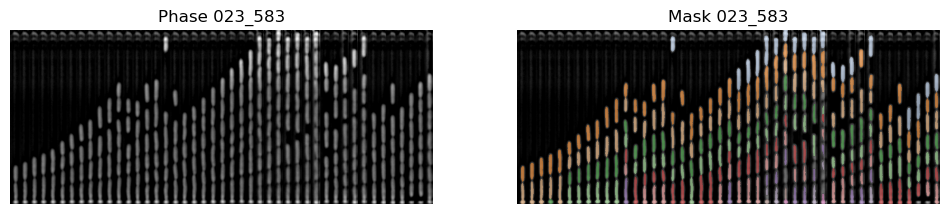

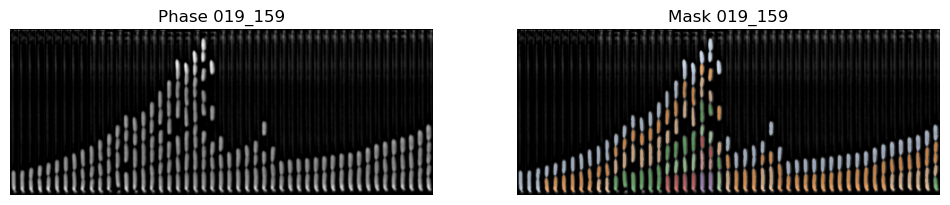

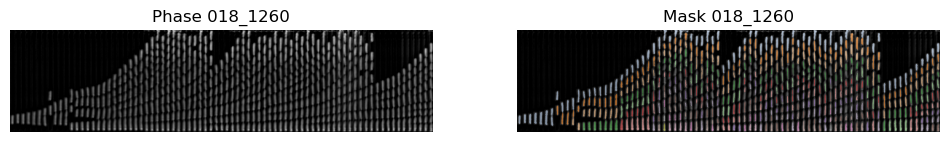

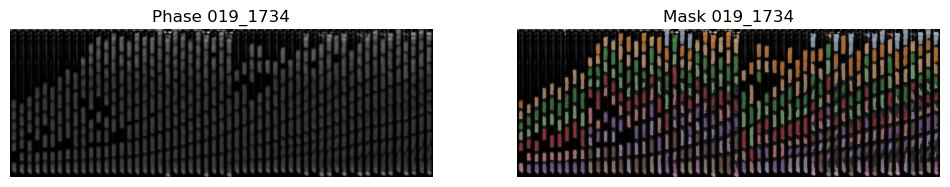

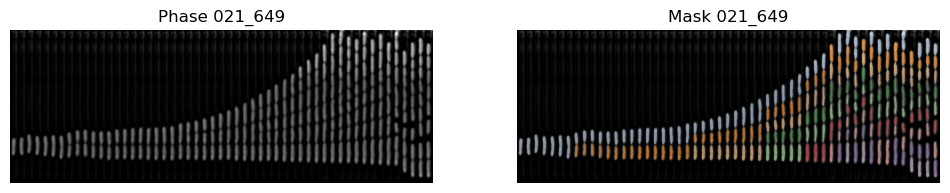

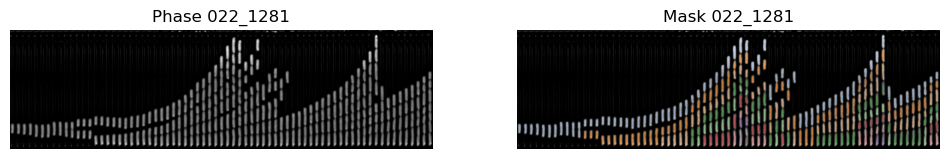

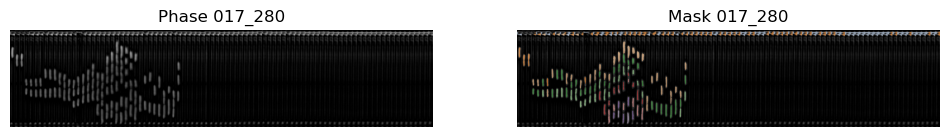

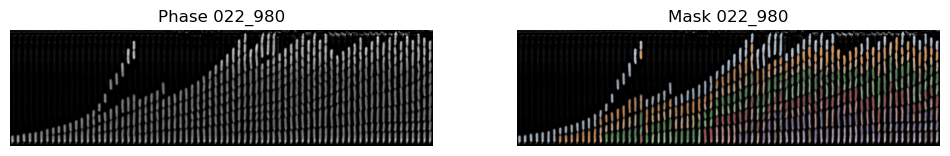

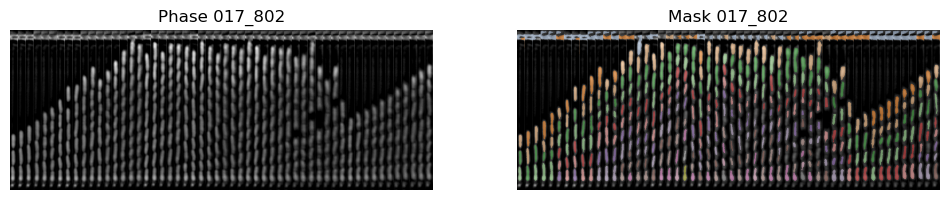

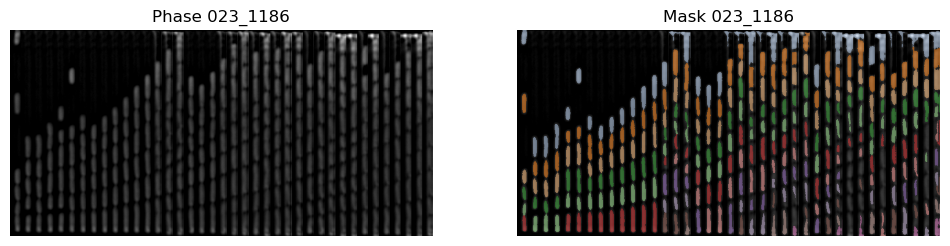

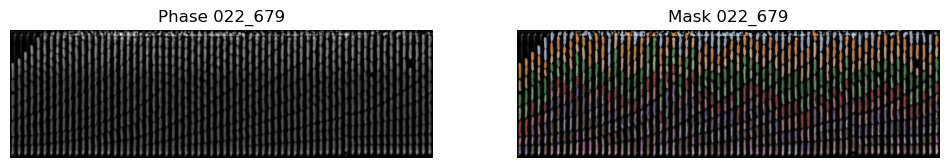

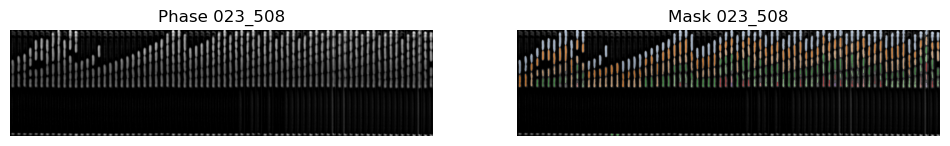

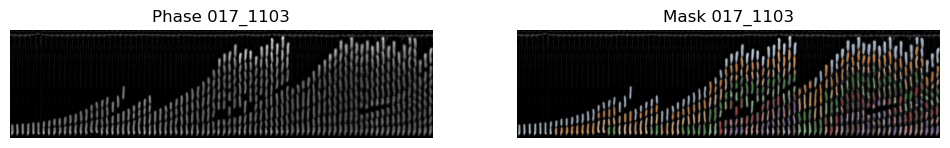

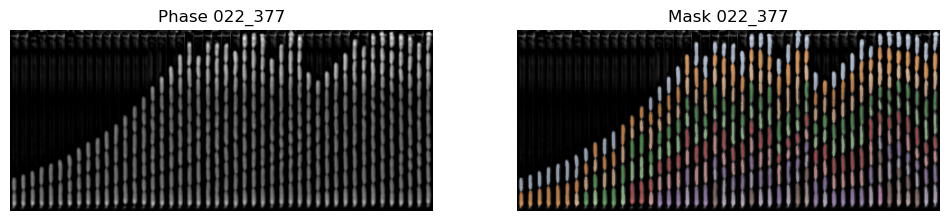

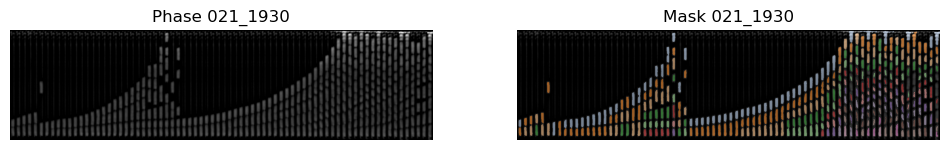

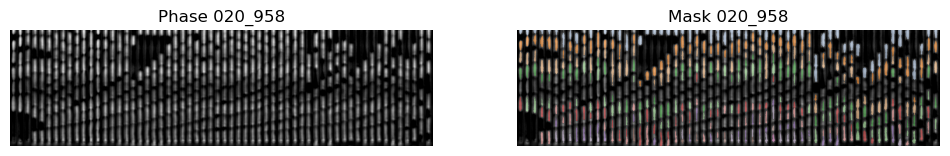

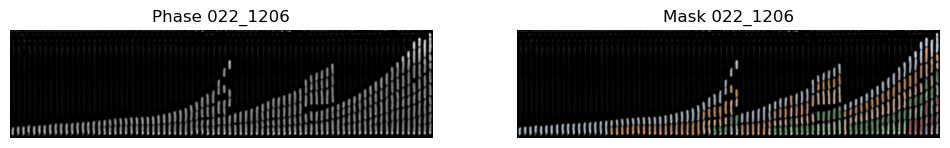

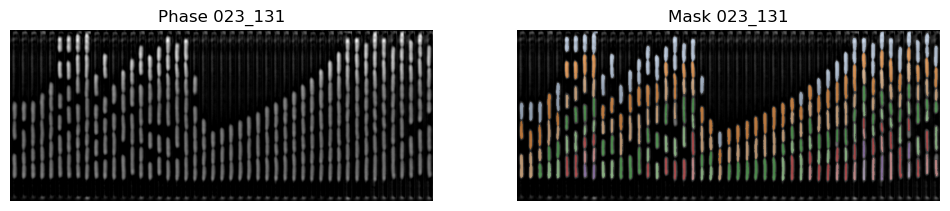

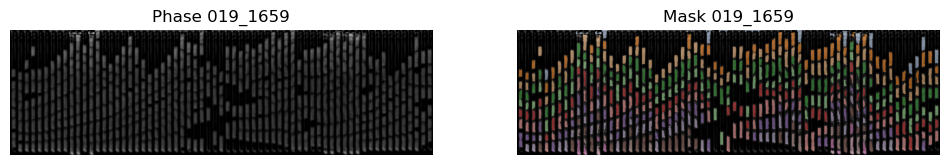

In [ ]:
experiment ='DUMM_gitg068_baeS_100225'
plot_all_functions(experiment)